In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [53]:
df=pd.read_csv("data_date.csv")

In [45]:
df.head()

,Date,Country,Status,AQI Value
0,2022-07-21,Albania,Good,14
1,2022-07-21,Algeria,Moderate,65
2,2022-07-21,Andorra,Moderate,55
3,2022-07-21,Angola,Unhealthy for Sensitive Groups,113
4,2022-07-21,Argentina,Moderate,63


In [46]:
df.fillna(0, inplace=True)

In [47]:
print(df.columns)

Index(['Date', 'Country', 'Status', 'AQI Value'], dtype='object')


In [48]:
print(X.columns)

Index(['AQI Value'], dtype='object')


In [49]:
X.head()

,AQI Value
0,14
1,65
2,55
3,113
4,63


In [50]:
X=df.drop(["AQI Value","Date", "Country", "Status"], axis=1)
y=df["AQI Value"]
X=df.select_dtypes(include=[np.number])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [61]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "SVM": SVR()
}
results = []

In [62]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

In [64]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
print(results_df)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  2.946003e-14  4.233405e-14  1.000000
1      Decision Tree  9.907121e-03  2.807920e-01  0.999967
2      Random Forest  1.000619e-02  2.841876e-01  0.999967
3                SVM  1.002188e+00  1.398565e+01  0.919350


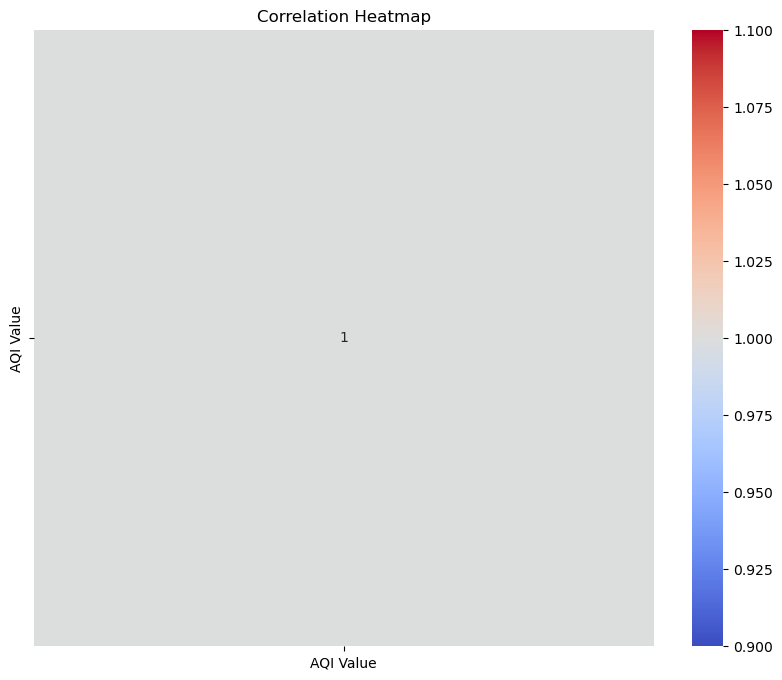

In [66]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

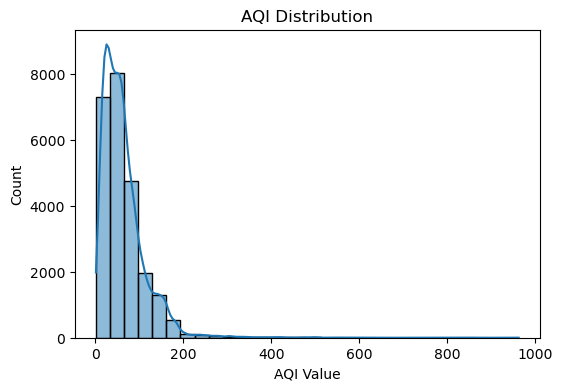

In [70]:
plt.figure(figsize=(6,4))
sns.histplot(df["AQI Value"], bins=30, kde=True)
plt.title("AQI Distribution")
plt.show()

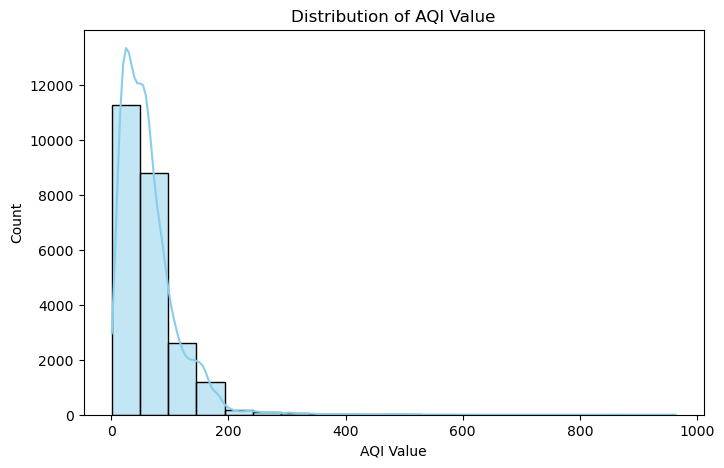

In [79]:
plt.figure(figsize=(8,5))
sns.histplot(df['AQI Value'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of AQI Value")
plt.xlabel("AQI Value")
plt.show()

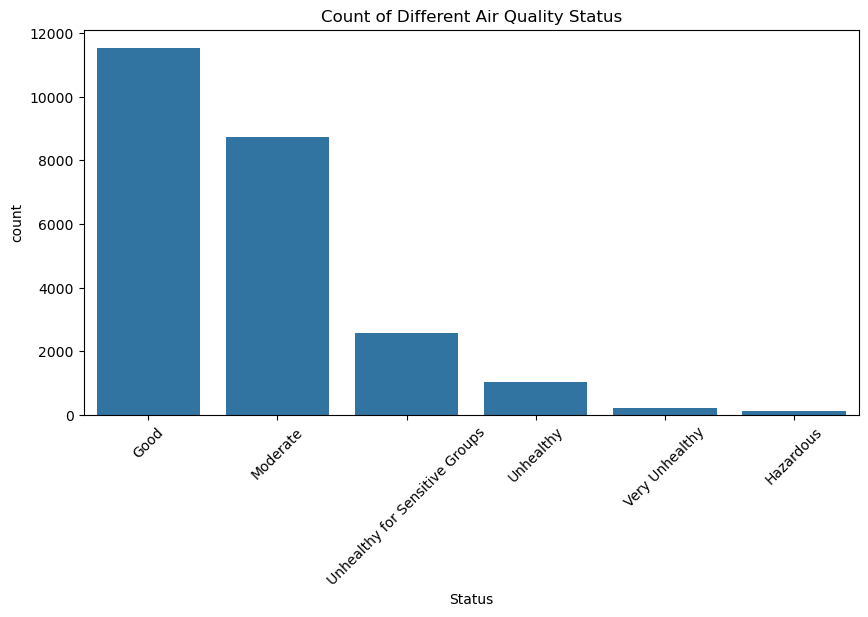

In [77]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Status')
plt.title("Count of Different Air Quality Status")
plt.xticks(rotation=45) 
plt.show()

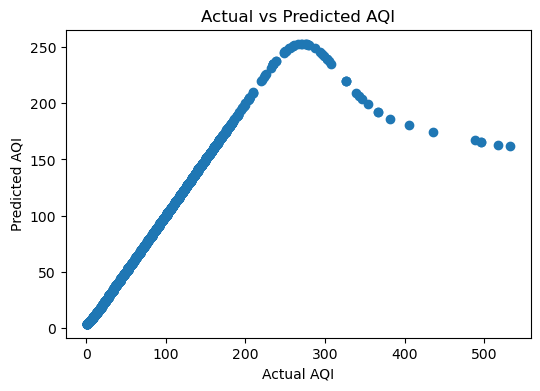

In [80]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()


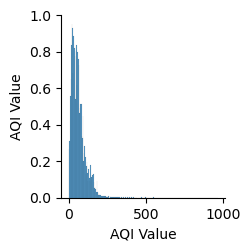

In [82]:
sns.pairplot(df)
plt.show()